In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '..')
import config
import re
import pandas as pd
import numpy as np
from pipeline import data_prep, plots
from pipeline.benchmark import deseq2_path, gene_level_compare, rescued_genes

## PyDESeq2 Benchmark — within-study Disease vs HC
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from scipy.sparse import issparse
import gseapy as gp

In [ ]:
dd = data_prep.load_disease_filtered()

## GET PyDeSEQ2 Result

### DESeq2

In [3]:
DESEQ2_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_results'
DESEQ2_DIR.mkdir(parents=True, exist_ok=True)
MP = config.MODELING_PARAMS


def deseq2_path(phenotype):
    stem = re.sub(r'[^A-Za-z0-9]+', '_', phenotype).strip('_')
    return DESEQ2_DIR / f'deseq2_{stem}.csv'


# Raw count extraction: prefer adata.raw, fall back to adata.X
_adata = dd.adata
if _adata.raw is not None:
    try:
        _raw_X = _adata.raw[:, _adata.var_names].X
        raw_counts_full = _raw_X.toarray() if issparse(_raw_X) else np.asarray(_raw_X)
    except Exception:
        raw_counts_full = _adata.X.toarray() if issparse(_adata.X) else np.asarray(_adata.X)
else:
    raw_counts_full = _adata.X.toarray() if issparse(_adata.X) else np.asarray(_adata.X)
raw_counts_full = np.round(raw_counts_full).astype(np.int64)

obs_names_list = _adata.obs_names.tolist()
obs2idx = {n: i for i, n in enumerate(obs_names_list)}
gene_ids = _adata.var_names.tolist()
id2sym_map = dict(zip(_adata.var_names, _adata.var['GeneName']))
name2pheno_ood = dict(zip(dd.dis_names, dd.dis_pheno))
unique_phenos_ood = sorted(np.unique(dd.dis_pheno))

deseq2_computed = {}

In [4]:
for phenotype in unique_phenos_ood:
    out_path = deseq2_path(phenotype)
    if out_path.exists():
        print(f'[{phenotype}] loading existing -> {out_path.name}')
        deseq2_computed[phenotype] = pd.read_csv(out_path)
        continue

    dis_names_ph = [n for n, ph in name2pheno_ood.items() if ph == phenotype]
    if len(dis_names_ph) < 2:
        print(f'[{phenotype}] skip: n_disease={len(dis_names_ph)} < 2')
        continue

    dis_obs = _adata.obs.loc[dis_names_ph]
    authors = dis_obs['Author'].unique().tolist()

    hc_mask = dd.is_hc & _adata.obs['Author'].isin(authors)
    hc_names_ph = _adata.obs_names[hc_mask].tolist()
    if len(hc_names_ph) < 2:
        print(f'[{phenotype}] skip: n_hc={len(hc_names_ph)} < 2 (authors={authors})')
        continue

    sample_names = dis_names_ph + hc_names_ph
    row_idx = [obs2idx[n] for n in sample_names]
    counts_arr = raw_counts_full[row_idx, :]
    counts_df = pd.DataFrame(counts_arr, index=sample_names, columns=gene_ids)
    counts_df = counts_df.loc[:, counts_df.sum(axis=0) >= 10]

    condition = ['Disease'] * len(dis_names_ph) + ['HC'] * len(hc_names_ph)
    author_raw = (dis_obs['Author'].tolist() +
                  _adata.obs.loc[hc_names_ph, 'Author'].tolist())
    author_clean = [re.sub(r'[^A-Za-z0-9]+', '_', a).strip('_') for a in author_raw]

    metadata = pd.DataFrame({
        'condition': pd.Categorical(condition, categories=['HC', 'Disease']),
        'Author_clean': author_clean,
    }, index=sample_names)

    n_authors = len(set(author_clean))
    design = '~Author_clean + condition' if n_authors > 1 else '~condition'

    try:
        inference = DefaultInference(n_cpus=4)
        dds = DeseqDataSet(
            counts=counts_df,
            metadata=metadata,
            design=design,
            refit_cooks=True,
            inference=inference,
        )
        dds.deseq2()

        ds = DeseqStats(dds, contrast=['condition', 'Disease', 'HC'], inference=inference)
        ds.summary()

        res = ds.results_df.copy()
        res.index.name = 'ensg'
        res = res.reset_index()
        res['symbol'] = res['ensg'].map(id2sym_map).fillna(res['ensg'])

        res.to_csv(out_path, index=False)
        deseq2_computed[phenotype] = res

        n_sig = int((res['padj'].dropna() < 0.05).sum())
        print(f'[{phenotype}] n_dis={len(dis_names_ph)} n_hc={len(hc_names_ph)} '
              f'design={repr(design)}  sig={n_sig}')
    except Exception as e:
        print(f'[{phenotype}] ERROR -- {e}')

print(f'Done: {len(deseq2_computed)} / {len(unique_phenos_ood)} phenotypes computed')

[CAD_HF+] loading existing -> deseq2_CAD_HF.csv
[CAD_HF-] loading existing -> deseq2_CAD_HF.csv
[Colorectal Cancer] loading existing -> deseq2_Colorectal_Cancer.csv
[Esophagus Cancer (Chen)] loading existing -> deseq2_Esophagus_Cancer_Chen.csv
[HIV] loading existing -> deseq2_HIV.csv
[HIV + Tuberculosis] loading existing -> deseq2_HIV_Tuberculosis.csv
[ICI-m] skip: n_hc=0 < 2 (authors=['Raissadati et al.'])
[ICI-treated Cancer] skip: n_hc=0 < 2 (authors=['Raissadati et al.'])
[Liver Cancer (Chen)] loading existing -> deseq2_Liver_Cancer_Chen.csv
[Liver Cancer (Roskams-Hieter)] loading existing -> deseq2_Liver_Cancer_Roskams_Hieter.csv
[Lung Cancer] loading existing -> deseq2_Lung_Cancer.csv
[ME/CFS] loading existing -> deseq2_ME_CFS.csv
[MGUS] loading existing -> deseq2_MGUS.csv
[MM] loading existing -> deseq2_MM.csv
[Other Cancer] loading existing -> deseq2_Other_Cancer.csv
[Pancreatic Cancer (Moore)] loading existing -> deseq2_Pancreatic_Cancer_Moore.csv


[Pancreatitis] loading existing -> deseq2_Pancreatitis.csv
[Pre-eclampsia] loading existing -> deseq2_Pre_eclampsia.csv
[Stomach Cancer] loading existing -> deseq2_Stomach_Cancer.csv
[Tuberculosis] loading existing -> deseq2_Tuberculosis.csv
Done: 18 / 20 phenotypes computed


### DESeq2 GSEA Result

In [5]:
# Requires deseq2_computed and deseq2_path() from the PyDESeq2 cell above.
GSEA_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_gsea'

deseq2_results = {}
all_phenos_for_gsea = list(deseq2_computed.keys()) if deseq2_computed else unique_phenos_ood

for phenotype in all_phenos_for_gsea:
    if phenotype in deseq2_computed:
        res_df = deseq2_computed[phenotype].copy()
    else:
        path = deseq2_path(phenotype)
        if not path.exists():
            print(f'[{phenotype}] no DESeq2 result -- skip GSEA')
            continue
        res_df = pd.read_csv(path)

    out_csv = GSEA_DIR / f"gsea_result_{phenotype.replace('/', '_')}.csv"
    if out_csv.exists():
        print(f'[{phenotype}] loading existing GSEA')
        deseq2_results[phenotype] = pd.read_csv(out_csv)
        continue

    res_df['stat'] = res_df['stat'].fillna(0.0)
    res_df['abs_stat'] = res_df['stat'].abs()
    res_df = (res_df.sort_values('abs_stat', ascending=False)
                    .drop_duplicates('symbol')
                    .drop(columns='abs_stat'))

    rnk = (res_df[['symbol', 'stat']]
           .rename(columns={'symbol': 'gene', 'stat': 'score'})
           .sort_values('score', ascending=False)
           .reset_index(drop=True))

    try:
        res = gp.prerank(
            rnk=rnk, gene_sets=MP['gsea_gene_sets'], outdir=None,
            min_size=10, max_size=500,
            permutation_num=MP['gsea_perm'], seed=MP['gsea_seed'], verbose=False)
        sig = res.res2d[res.res2d['FDR q-val'] < MP['gsea_fdr_thr']].copy()
        sig.to_csv(out_csv, index=False)
        deseq2_results[phenotype] = sig
        sig['NES'] = pd.to_numeric(sig['NES'], errors='coerce')
        n_up = int((sig['NES'] > 0).sum())
        n_dn = int((sig['NES'] < 0).sum())
        print(f'[{phenotype}] {len(sig):4d} sig  (NES>0: {n_up:3d}  NES<0: {n_dn:3d})')
    except Exception as e:
        print(f'[{phenotype}] GSEA ERROR -- {e}')

print(f'Done: {len(deseq2_results)} phenotypes with GSEA results')

deseq2_fig_dir = GSEA_DIR / 'gsea_dotplot'
plots.plot_gsea_dotplots(deseq2_results, fig_dir=deseq2_fig_dir)

[CAD_HF+] loading existing GSEA
[CAD_HF-] loading existing GSEA
[Colorectal Cancer] loading existing GSEA
[Esophagus Cancer (Chen)] loading existing GSEA
[HIV] loading existing GSEA
[HIV + Tuberculosis] loading existing GSEA
[Liver Cancer (Chen)] loading existing GSEA
[Liver Cancer (Roskams-Hieter)] loading existing GSEA
[Lung Cancer] loading existing GSEA
[ME/CFS] loading existing GSEA
[MGUS] loading existing GSEA
[MM] loading existing GSEA
[Other Cancer] loading existing GSEA
[Pancreatic Cancer (Moore)] loading existing GSEA
[Pancreatitis] loading existing GSEA
[Pre-eclampsia] loading existing GSEA
[Stomach Cancer] loading existing GSEA
[Tuberculosis] loading existing GSEA
Done: 18 phenotypes with GSEA results


[CAD_HF+] GSEA Plots generated successfully.


[CAD_HF-] GSEA Plots generated successfully.


[Colorectal Cancer] GSEA Plots generated successfully.


[Esophagus Cancer (Chen)] GSEA Plots generated successfully.


...

[Pancreatic Cancer (Moore)] GSEA Plots generated successfully.


[Pancreatitis] GSEA Plots generated successfully.


[Pre-eclampsia] GSEA Plots generated successfully.


[Stomach Cancer] GSEA Plots generated successfully.


[Tuberculosis] GSEA Plots generated successfully.


## DESeq2 Benchmark — Analysis 1: Genes Rescued by Normative Modeling

In [6]:
unique_phenos = pd.Series(dd.dis_pheno).unique()

Esophagus Cancer (Chen)


genes compared: 18614  |  DESeq2-excluded: 35
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Esophagus_Cancer_(Chen).csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


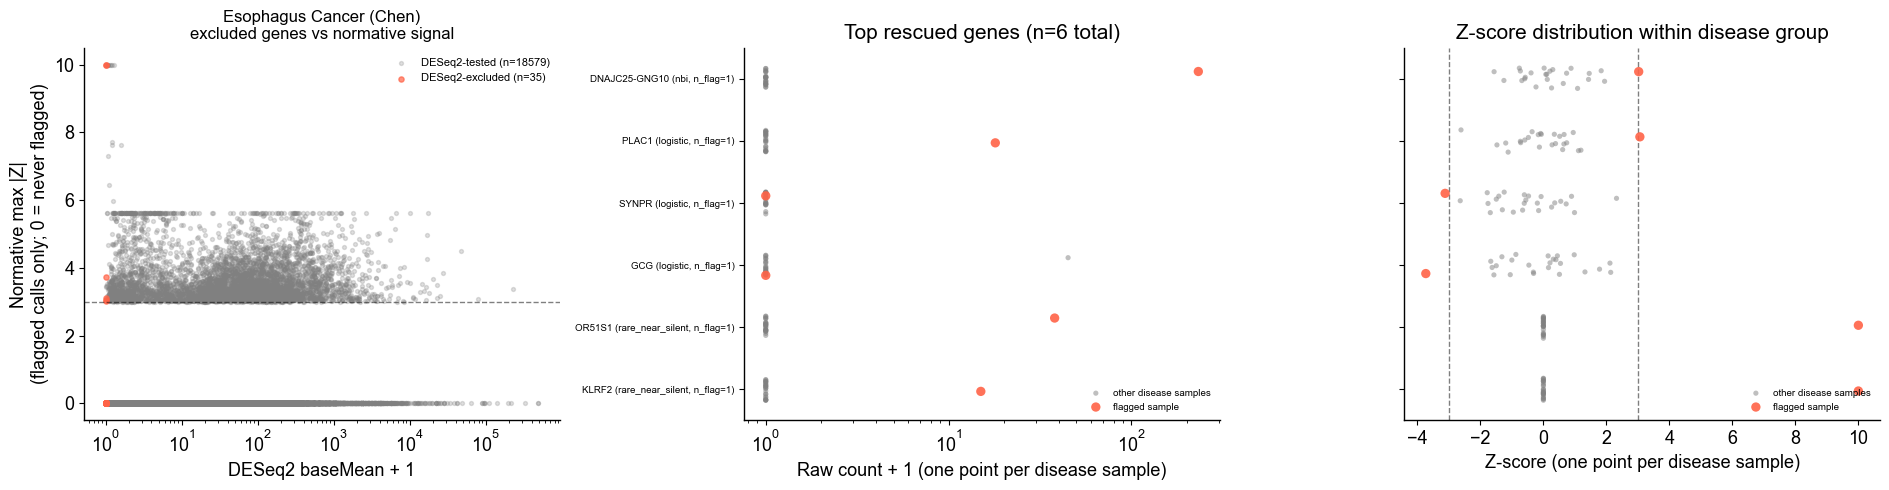

Lung Cancer


genes compared: 18646  |  DESeq2-excluded: 40
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Lung_Cancer.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


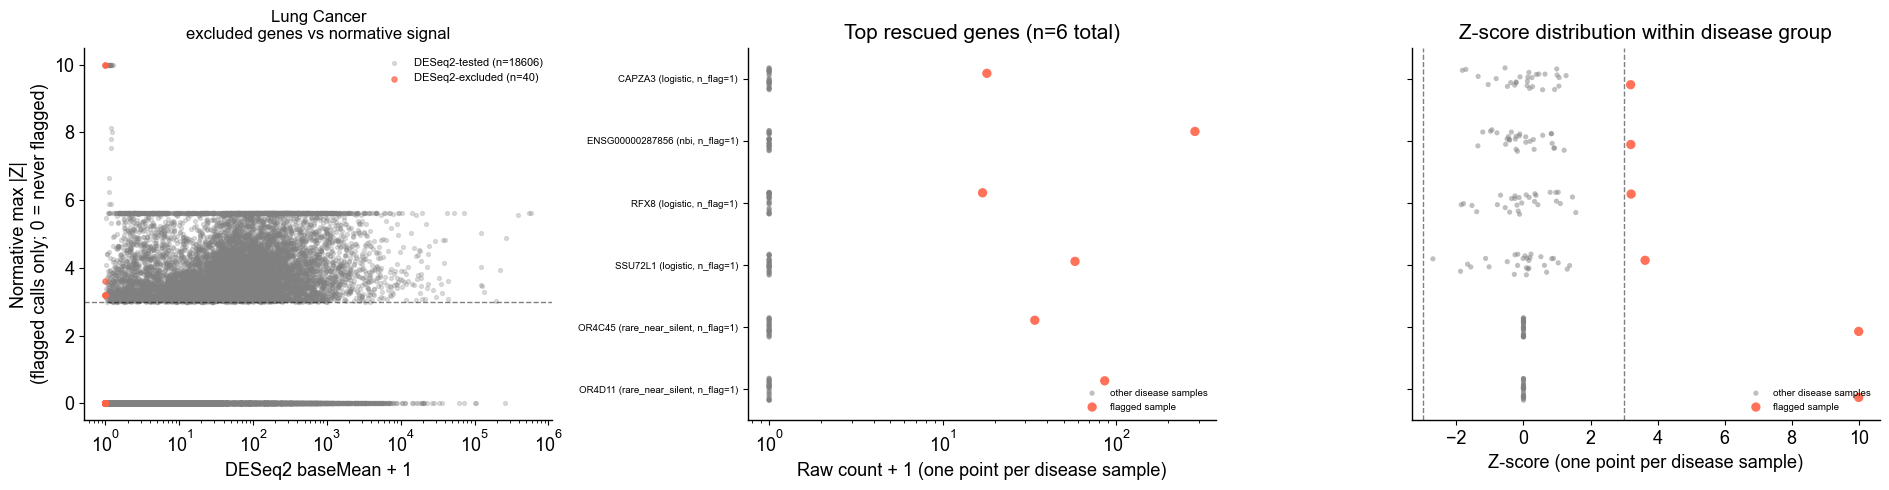

Liver Cancer (Chen)
genes compared: 18538  |  DESeq2-excluded: 68
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Liver_Cancer_(Chen).csv


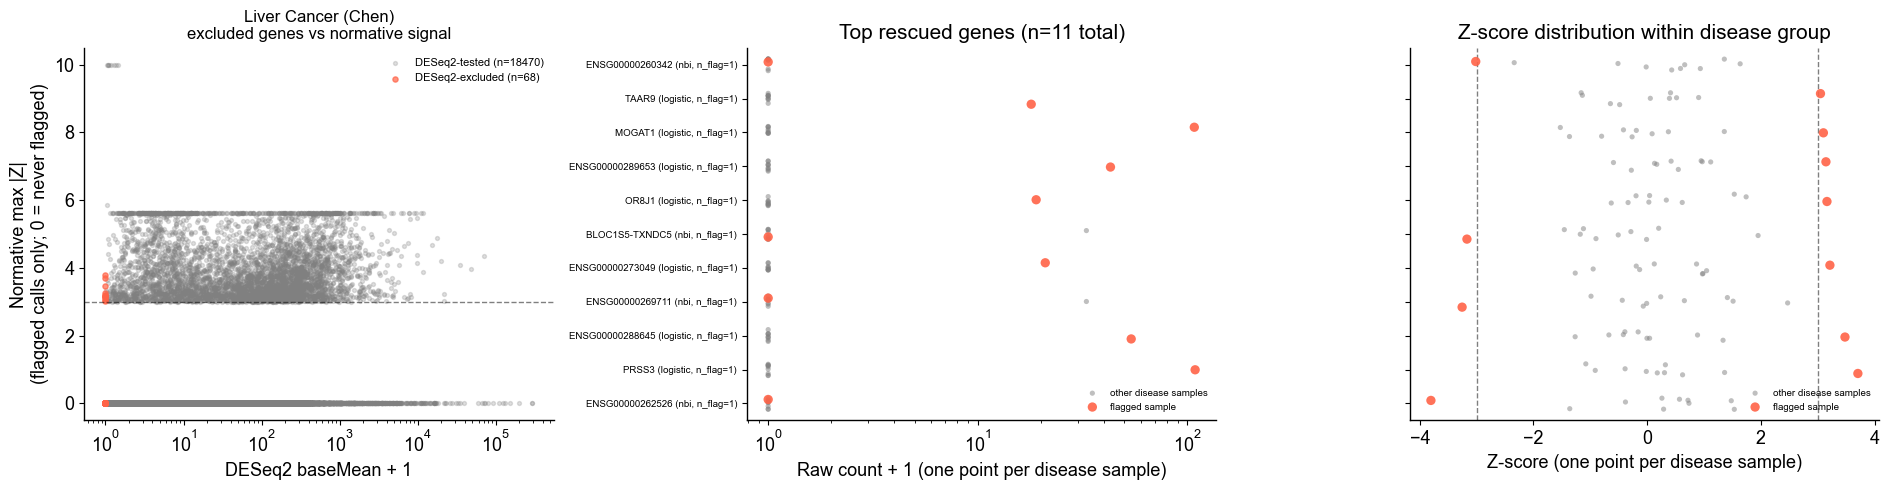

Stomach Cancer
genes compared: 18545  |  DESeq2-excluded: 37
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Stomach_Cancer.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


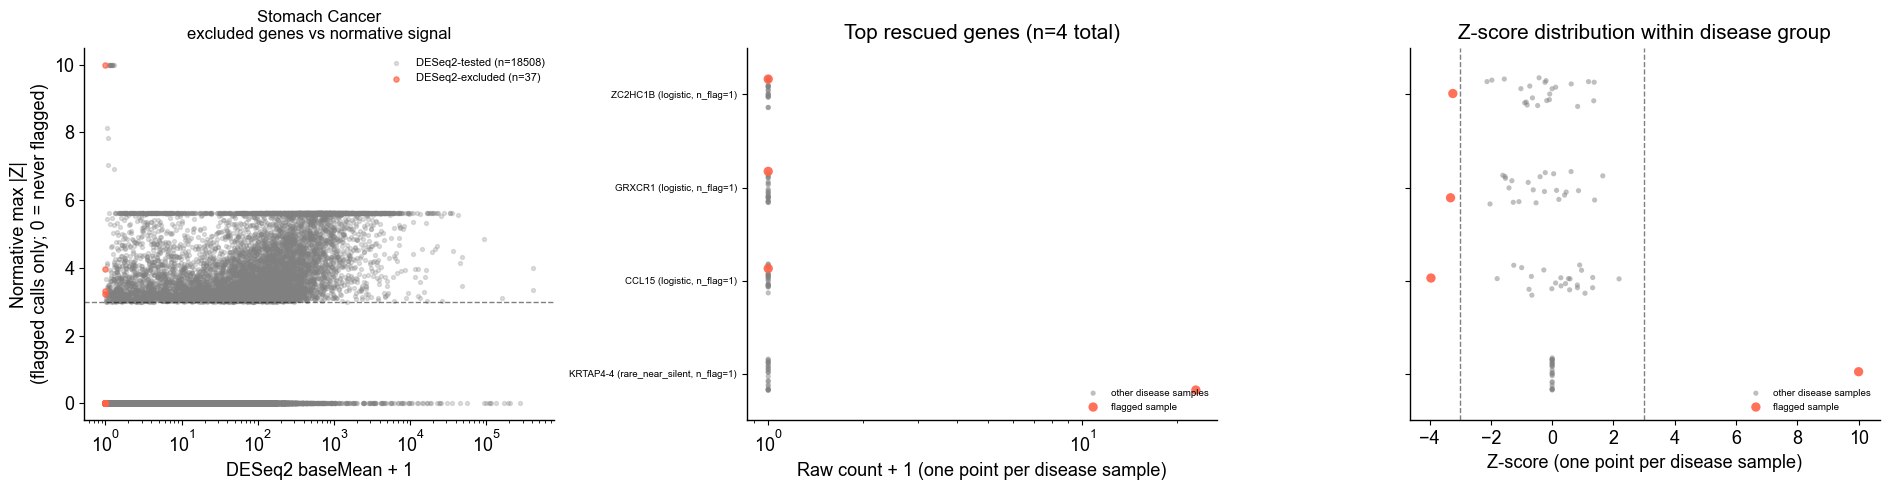

Colorectal Cancer
genes compared: 18408  |  DESeq2-excluded: 46
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Colorectal_Cancer.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


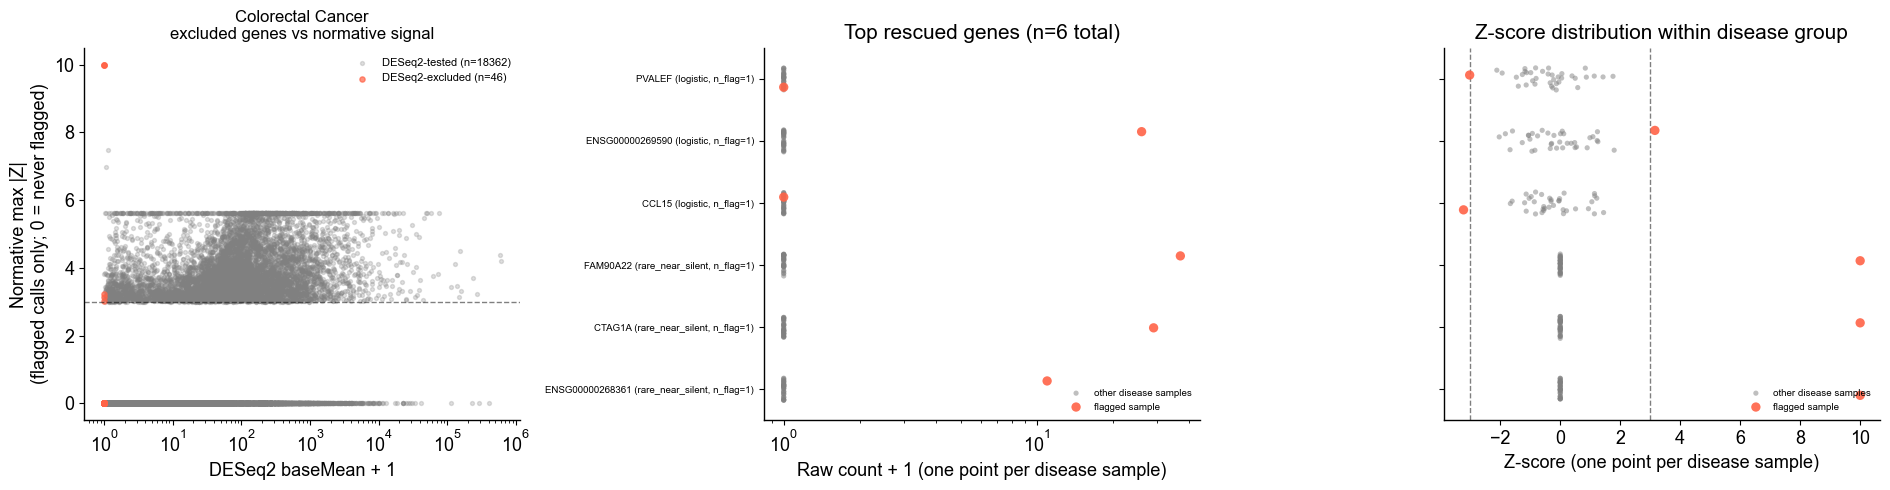

MM
genes compared: 18239  |  DESeq2-excluded: 32
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_MM.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


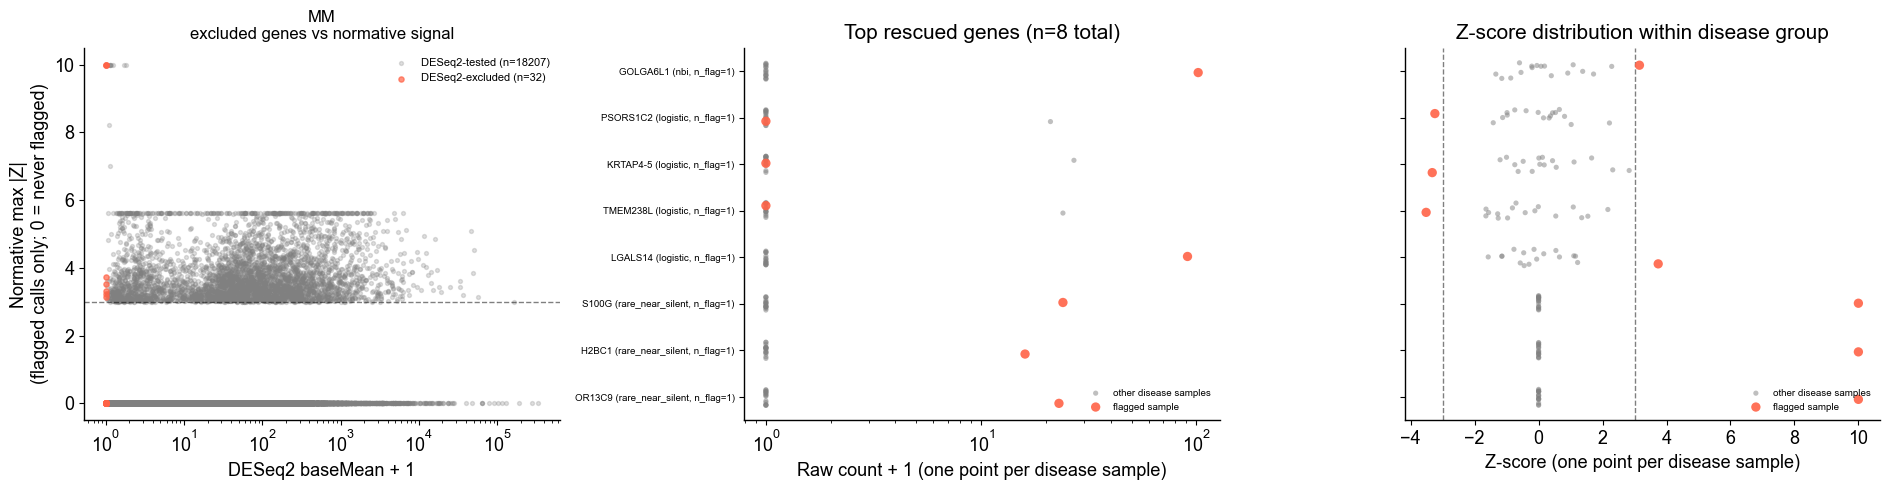

MGUS
genes compared: 18069  |  DESeq2-excluded: 40
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_MGUS.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


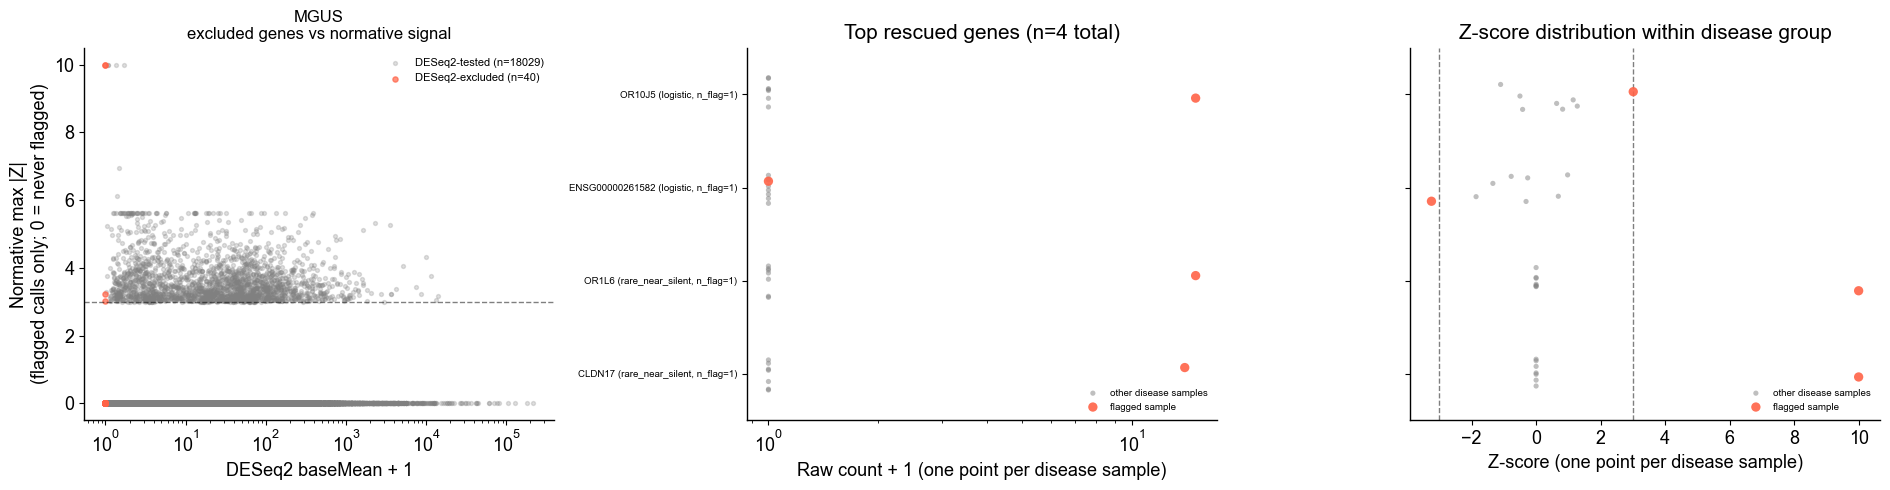

Liver Cancer (Roskams-Hieter)
genes compared: 18466  |  DESeq2-excluded: 44
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Liver_Cancer_(Roskams-Hieter).csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


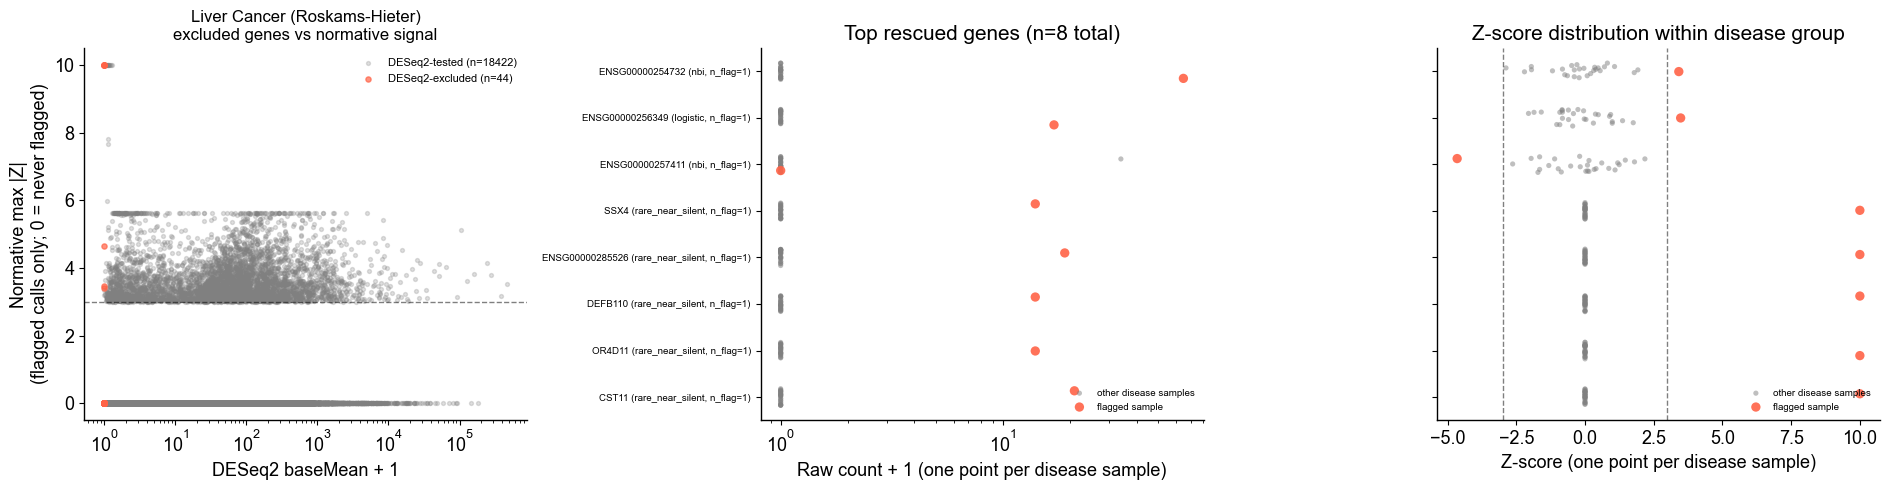

Pre-eclampsia
genes compared: 18805  |  DESeq2-excluded: 70
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Pre-eclampsia.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


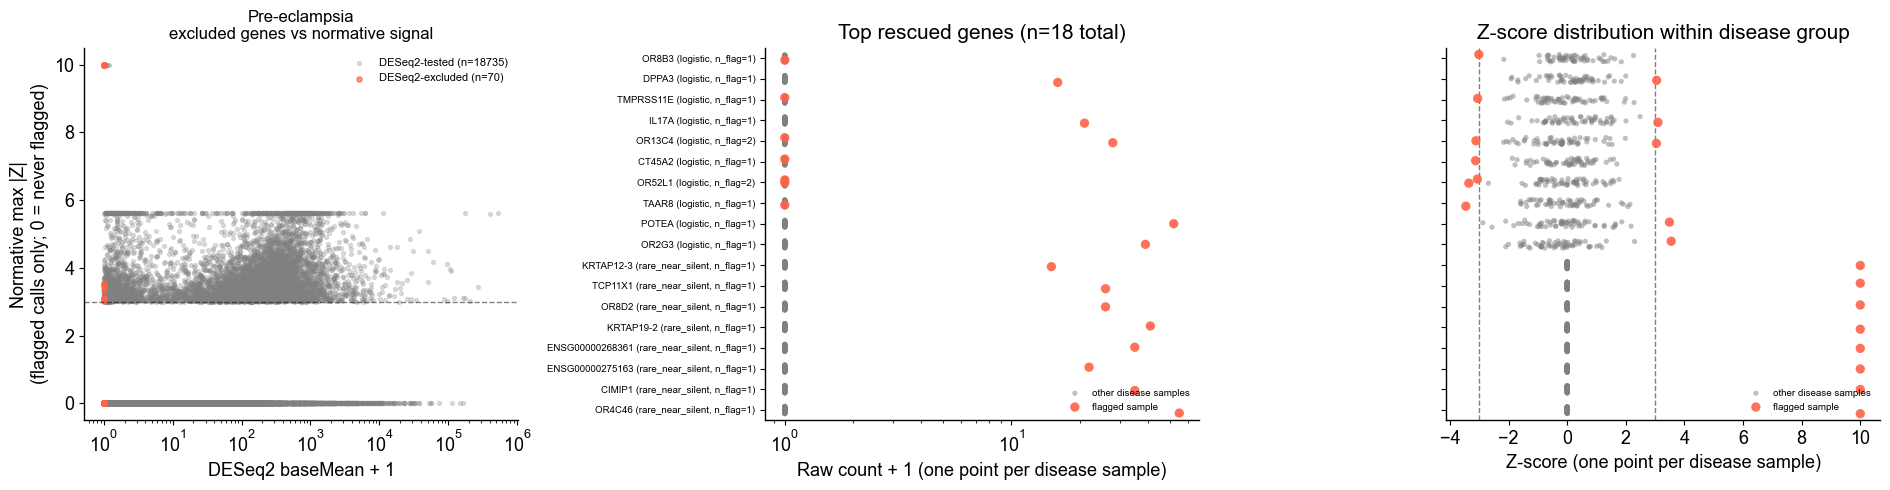

CAD_HF-
genes compared: 18758  |  DESeq2-excluded: 1
No Rescued Genes in CAD_HF-, Skipped.
CAD_HF+


genes compared: 18758  |  DESeq2-excluded: 1
No Rescued Genes in CAD_HF+, Skipped.
Pancreatitis
genes compared: 18582  |  DESeq2-excluded: 112
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Pancreatitis.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


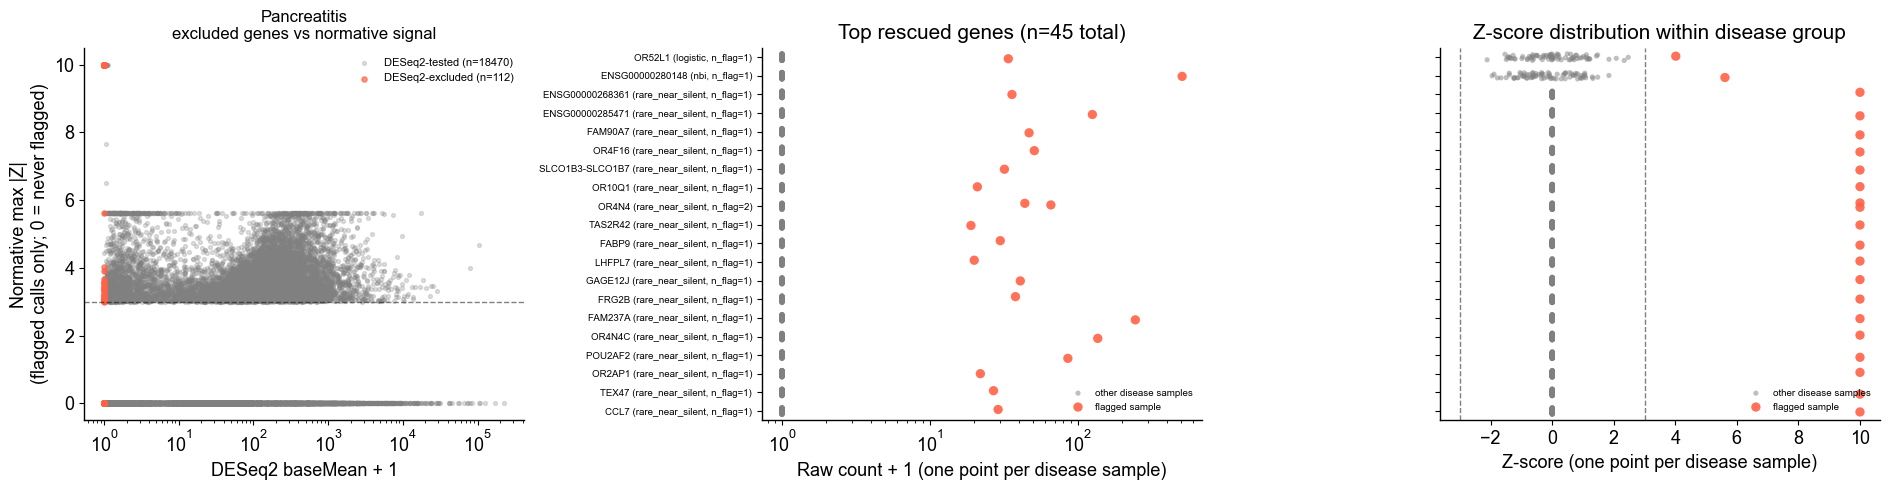

Other Cancer
genes compared: 18016  |  DESeq2-excluded: 140
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Other_Cancer.csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


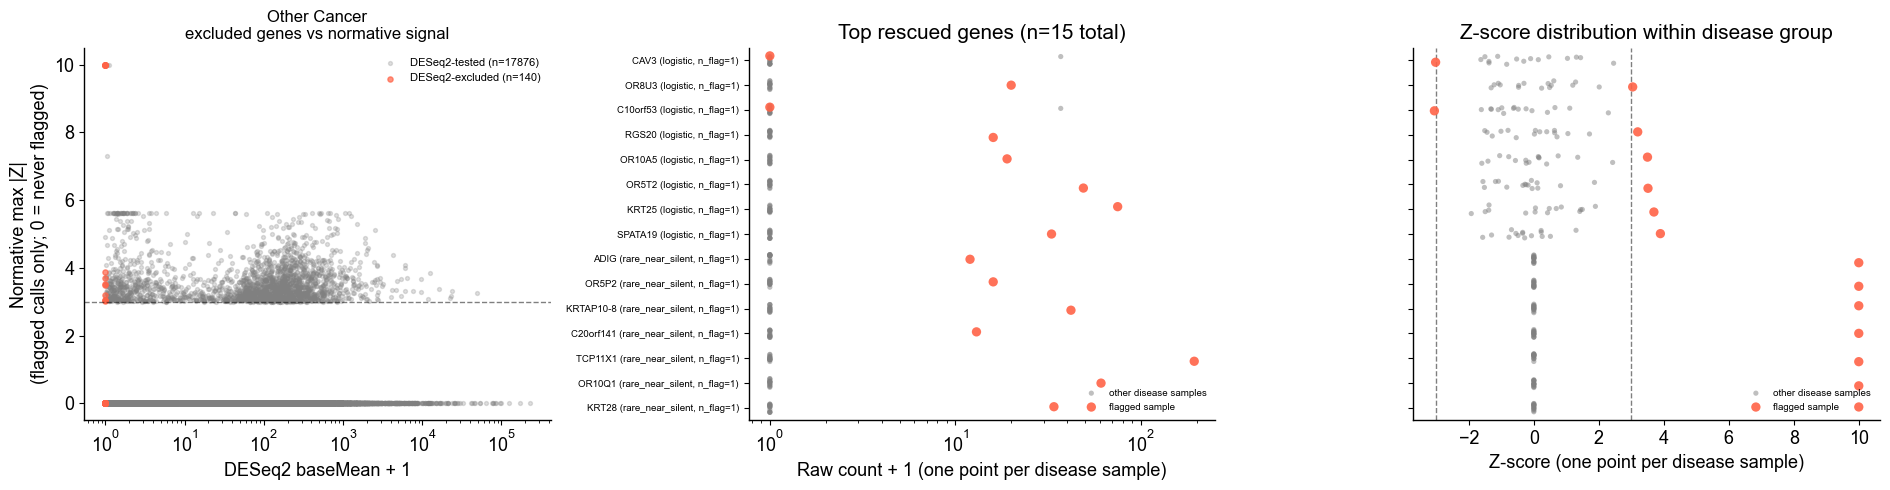

Pancreatic Cancer (Moore)
genes compared: 18651  |  DESeq2-excluded: 121
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Pancreatic_Cancer_(Moore).csv


Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


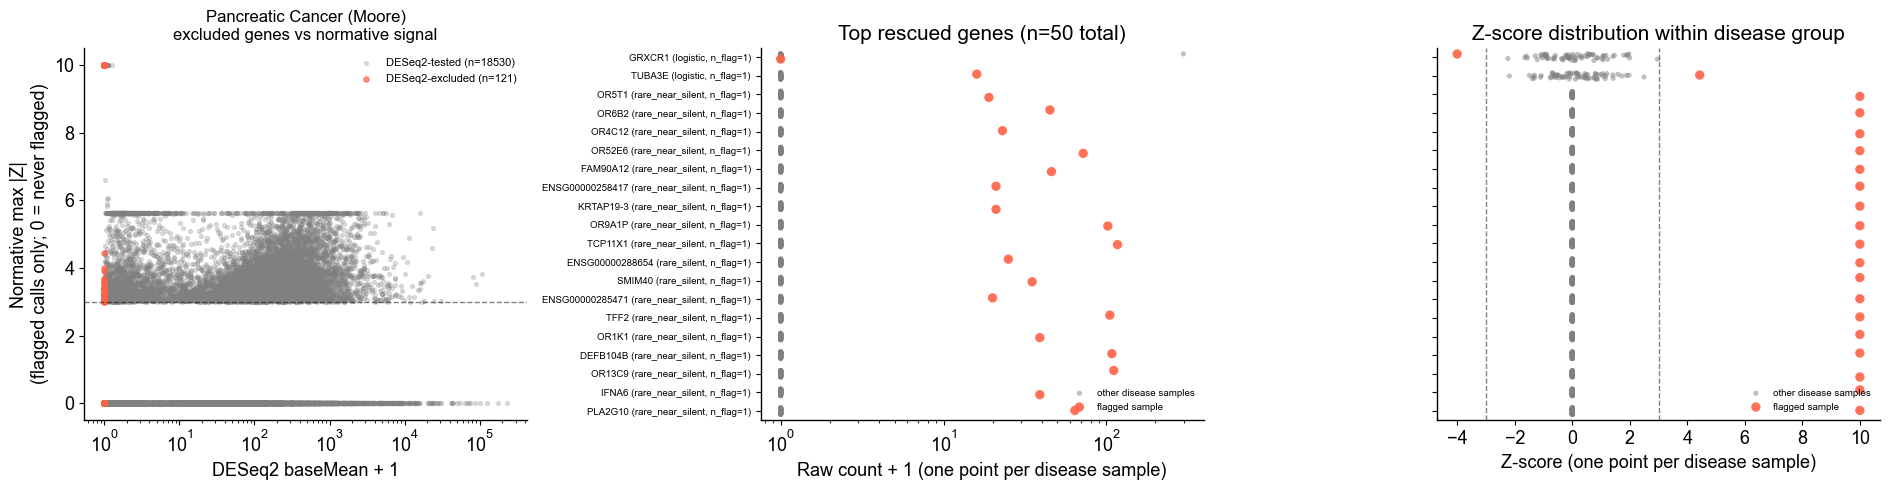

HIV + Tuberculosis
genes compared: 17642  |  DESeq2-excluded: 0
No Rescued Genes in HIV + Tuberculosis, Skipped.
Tuberculosis


genes compared: 18549  |  DESeq2-excluded: 0
No Rescued Genes in Tuberculosis, Skipped.
HIV
genes compared: 17538  |  DESeq2-excluded: 1
No Rescued Genes in HIV, Skipped.
ME/CFS


genes compared: 17305  |  DESeq2-excluded: 1
No Rescued Genes in ME/CFS, Skipped.
ICI-m
No DESeq2 result for ICI-m, Skipped.
ICI-treated Cancer
No DESeq2 result for ICI-treated Cancer, Skipped.


In [7]:
for PHENOTYPE in unique_phenos : 
    print(PHENOTYPE)
    if not deseq2_path(PHENOTYPE).exists():
        print(f"No DESeq2 result for {PHENOTYPE}, Skipped.")
        continue

    merged = gene_level_compare(dd, PHENOTYPE)
    print(f"genes compared: {len(merged)}  |  DESeq2-excluded: {merged['excluded'].sum()}")
    rescued = rescued_genes(merged)
    if len(rescued) == 0:
        print(f"No Rescued Genes in {PHENOTYPE}, Skipped.")
        continue 

    out_path = config.BENCHMARK_DIR / f"rescued_genes_{PHENOTYPE.replace(' ', '_').replace('/', '_')}.csv"
    rescued.to_csv(out_path, index=False)
    print(f'saved -> {out_path}')
    _ = plots.plot_rescued_genes(merged, rescued, PHENOTYPE, dd=dd)